# Exploración computacional de la regresión logística

Este cuaderno **no redefine** ninguna función: todo se importa desde `src/`.
Ejecutar de principio a fin con un kernel reiniciado debe reproducir
exactamente estos resultados.

In [1]:
import sys
sys.path.append("..")  # para poder importar el paquete src/ desde notebooks/

import numpy as np
import matplotlib.pyplot as plt

from src.modelo import sigmoid, p_theta, riesgo_empirico
from src.optimizacion import ajustar_modelo
from src.simulacion import generar_datos

## Ejercicio 1 — Superficie del riesgo logístico

Datos del enunciado y malla de valores de $\theta=(\theta_0,\theta_1)$.

In [2]:
x = np.array([-2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2])
y = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])

theta0_vals = np.linspace(-4, 4, 100)
theta1_vals = np.linspace(-1, 6, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

# R_S(theta0, theta1) evaluado en cada punto de la malla.
# riesgo_empirico espera theta=(theta0,theta1) escalares, así que
# recorremos la malla explícitamente (es 100x100 = 10000 evaluaciones,
# rápido para este tamaño de datos).
R = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        R[i, j] = riesgo_empirico((T0[i, j], T1[i, j]), x, y)

**(a)** Ya evaluado arriba (`R`). **(b)** Superficie 3D y curvas de nivel:

In [3]:
# (c) Optimizar desde (0,0)
theta_hat, resultado = ajustar_modelo(x, y, theta_init=np.array([0.0, 0.0]))
R_hat = riesgo_empirico(theta_hat, x, y)
print("theta_hat =", theta_hat)
print("R_S(theta_hat) =", R_hat)

theta_hat = [0.650009   2.58448745]
R_S(theta_hat) = 0.2784542389232336


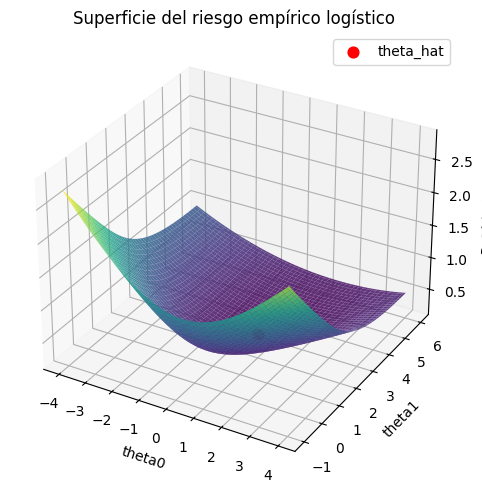

In [4]:
# (b) Superficie 3D
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(T0, T1, R, cmap="viridis", alpha=0.85)
ax.scatter([theta_hat[0]], [theta_hat[1]], [R_hat], color="red", s=60, label="theta_hat")
ax.set_xlabel("theta0")
ax.set_ylabel("theta1")
ax.set_zlabel("R_S(theta)")
ax.set_title("Superficie del riesgo empírico logístico")
ax.legend()
plt.tight_layout()
plt.savefig("../resultados/ej1_superficie.png", dpi=150)
plt.show()

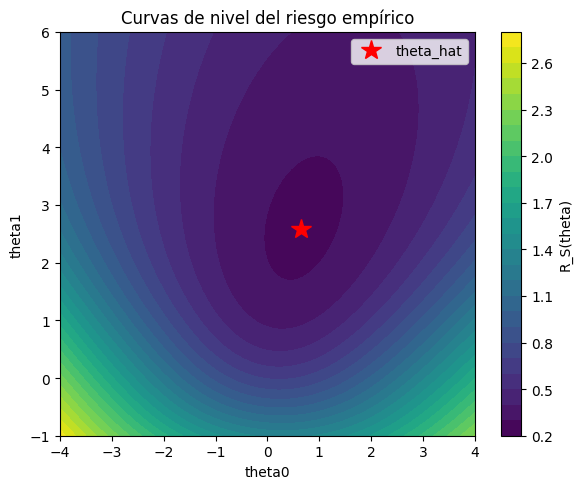

In [5]:
# (b) Curvas de nivel, con el minimizador marcado (d)
fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(T0, T1, R, levels=30, cmap="viridis")
ax.plot(theta_hat[0], theta_hat[1], "r*", markersize=15, label="theta_hat")
ax.set_xlabel("theta0")
ax.set_ylabel("theta1")
ax.set_title("Curvas de nivel del riesgo empírico")
fig.colorbar(cf, ax=ax, label="R_S(theta)")
ax.legend()
plt.tight_layout()
plt.savefig("../resultados/ej1_curvas_nivel.png", dpi=150)
plt.show()

**(d)** Verificación numérica de que theta_hat es un mínimo local (en las dos direcciones de los ejes):

In [6]:
R_mas_theta0 = riesgo_empirico(theta_hat + np.array([0.1, 0.0]), x, y)
R_mas_theta1 = riesgo_empirico(theta_hat + np.array([0.0, 0.1]), x, y)

print("R_S(theta_hat)              =", R_hat)
print("R_S(theta_hat + (0.1, 0))   =", R_mas_theta0, " -> cumple:", R_hat < R_mas_theta0)
print("R_S(theta_hat + (0, 0.1))   =", R_mas_theta1, " -> cumple:", R_hat < R_mas_theta1)

R_S(theta_hat)              = 0.2784542389232336
R_S(theta_hat + (0.1, 0))   = 0.27888134435896883  -> cumple: True
R_S(theta_hat + (0, 0.1))   = 0.2786645916335658  -> cumple: True


## Ejercicio 2 — Datos separables y no separables

In [7]:
y_A = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])   # separable
y_B = np.array([0, 0, 0, 1, 0, 1, 1, 1, 1])   # no separable

theta_hat_A, _ = ajustar_modelo(x, y_A)
theta_hat_B, _ = ajustar_modelo(x, y_B)

R_A = riesgo_empirico(theta_hat_A, x, y_A)
R_B = riesgo_empirico(theta_hat_B, x, y_B)

In [8]:
# (b) Tabla resumen
print(f"{'conjunto':10s} {'||theta_hat||^2':>18s} {'R_S(theta_hat)':>16s}")
print(f"{'A':10s} {np.sum(theta_hat_A**2):18.4f} {R_A:16.6f}")
print(f"{'B':10s} {np.sum(theta_hat_B**2):18.4f} {R_B:16.6f}")

conjunto      ||theta_hat||^2   R_S(theta_hat)
A                   1853.1438         0.000010
B                      7.1021         0.278454


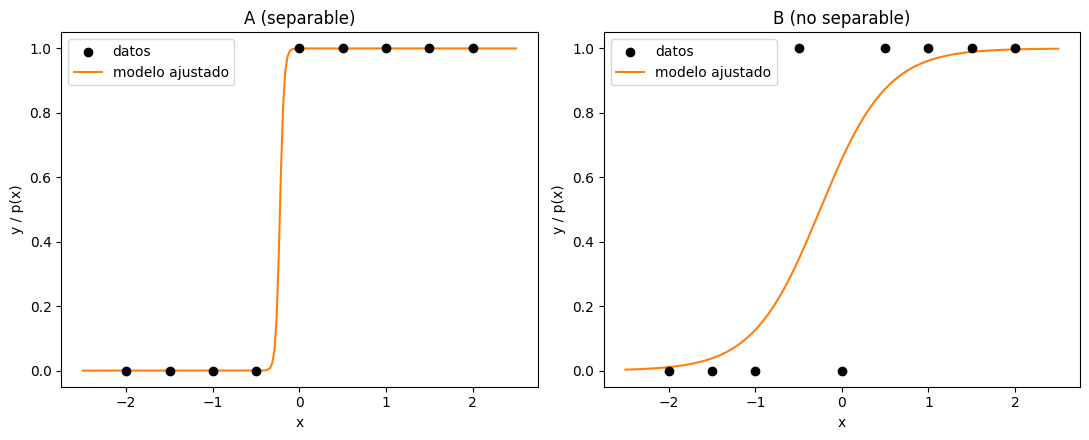

In [9]:
# (c) Datos y curva ajustada, un conjunto en cada panel
x_curva = np.linspace(-2.5, 2.5, 200)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nombre, yy, th) in zip(
    axes, [("A (separable)", y_A, theta_hat_A), ("B (no separable)", y_B, theta_hat_B)]
):
    ax.scatter(x, yy, color="black", zorder=3, label="datos")
    ax.plot(x_curva, p_theta(th, x_curva), color="C1", label="modelo ajustado")
    ax.set_title(nombre)
    ax.set_xlabel("x")
    ax.set_ylabel("y / p(x)")
    ax.legend()
plt.tight_layout()
plt.savefig("../resultados/ej2_ajustes.png", dpi=150)
plt.show()

**(d)** Comparación de `maxiter=10` vs `maxiter=100` sobre el conjunto separable (A):

In [10]:
theta_10, _ = ajustar_modelo(x, y_A, maxiter=10)
theta_100, _ = ajustar_modelo(x, y_A, maxiter=100)

norma_10, R_10 = np.sum(theta_10**2), riesgo_empirico(theta_10, x, y_A)
norma_100, R_100 = np.sum(theta_100**2), riesgo_empirico(theta_100, x, y_A)

print(f"maxiter=10  -> ||theta||^2 = {norma_10:.4f}, R_S = {R_10:.6f}")
print(f"maxiter=100 -> ||theta||^2 = {norma_100:.4f}, R_S = {R_100:.6f}")
print()
print("La norma aumenta:", norma_100 > norma_10)
print("El riesgo disminuye:", R_100 < R_10)
print("=> Afirmación compatible: II (la norma aumenta mientras el riesgo disminuye hacia cero)")

maxiter=10  -> ||theta||^2 = 256.8653, R_S = 0.005126
maxiter=100 -> ||theta||^2 = 1853.1438, R_S = 0.000010

La norma aumenta: True
El riesgo disminuye: True
=> Afirmación compatible: II (la norma aumenta mientras el riesgo disminuye hacia cero)


## Ejercicio 3 — Recuperación de parámetros

Modelo generador: $P(Y=1\mid X=x)=\sigma(-1+2x)$, es decir $\theta^\star=(-1, 2)$.

In [11]:
theta_star = np.array([-1.0, 2.0])
rng = np.random.default_rng(2026)  # un único rng, se reutiliza para los 3 tamaños

resultados_ej3 = []
for n in [50, 200, 1000]:
    x_n, y_n = generar_datos(n, theta_star, rng)
    theta_hat_n, _ = ajustar_modelo(x_n, y_n)
    e_n = np.linalg.norm(theta_hat_n - theta_star)
    resultados_ej3.append((n, theta_hat_n[0], theta_hat_n[1], e_n))

In [12]:
print(f"{'n':>6s} {'theta0_hat':>12s} {'theta1_hat':>12s} {'e_n':>10s}")
for n, t0, t1, e in resultados_ej3:
    print(f"{n:6d} {t0:12.4f} {t1:12.4f} {e:10.4f}")

n_mejor = min(resultados_ej3, key=lambda fila: fila[3])[0]
e_50 = [fila[3] for fila in resultados_ej3 if fila[0] == 50][0]
e_1000 = [fila[3] for fila in resultados_ej3 if fila[0] == 1000][0]

print()
print("n con menor error:", n_mejor)
print("¿e_1000 < e_50?", e_1000 < e_50)

     n   theta0_hat   theta1_hat        e_n
    50      -1.6138       2.6844     0.9193
   200      -0.8230       2.0382     0.1811
  1000      -1.0660       1.8500     0.1639

n con menor error: 1000
¿e_1000 < e_50? True
